In [4]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [5]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
    's1000ns_mw1',  's1000ns_mw3',  's1000ns_mw5',  's1000ns_mw7','s1000ns_mw15',
    's2000ns_mw3',  's2000ns_mw5',  's2000ns_mw7',
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pygama.pargen.energy_cal as pgc
import pygama.pargen.survival_fractions as sf

In [7]:
# FIT_CONFIGS = {
#     "dep": {
#         "range": (1565.0, 1615.0),
#         "peak": 1592.5,
#         "func": sf.gauss_on_step,
#     },
#     "sep": {
#         "range": (2070.0, 2140.0),
#         "peak": 2103.5,
#         "func": sf.hpge_peak,
#     },
#     "fep": {
#         "range": (2580.0, 2645.0),
#         "peak": 2614.5,
#         "func": sf.hpge_peak,
#     },
# }

In [ ]:
run_1 = "s40ns_mw7"
run_2 = "s300ns_mw7"

## DEP

### readfile

In [9]:
pathlist = "cal_pathlist"

In [10]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_1][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_1][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db[run_1][pathlist])
low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_1][pathlist])

In [11]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)
low_cut_1 = np.asarray(low_cut_1)

In [12]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_2][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_2][pathlist])
is_valid_waveform_2= lh5.read("ch002/hit/is_valid_waveform",run_db[run_2][pathlist])
low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_2][pathlist])

In [13]:
E_2 = np.asarray(E_2)
A_max_mw_o_E_Classifier_2= np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_2 = np.asarray(is_valid_waveform_2)
low_cut_2 = np.asarray(low_cut_2)   

In [14]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)

In [15]:
DEP_mask = (E_1 > 1585) & (E_1 < 1600)
cut_value_1 = survival_db[run_1]['cut_value_90']
cut_value_2 = survival_db[run_2]['cut_value_90']

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [17]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == DEP_mask.shape
    == low_cut_1.shape
    == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"DEP_mask={DEP_mask.shape}, "
    f"low_cut_1={low_cut_1.shape}, "
    f"low_cut_2={low_cut_2.shape}"
)

# DEP selection plus finite classifier values
selection = (
    DEP_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# Selected Boolean cut decisions
pass_1 = low_cut_1[selection]
pass_2 = low_cut_2[selection]

print(f"Selected DEP events: {len(x):,}")

Selected DEP events: 3,875


### plots

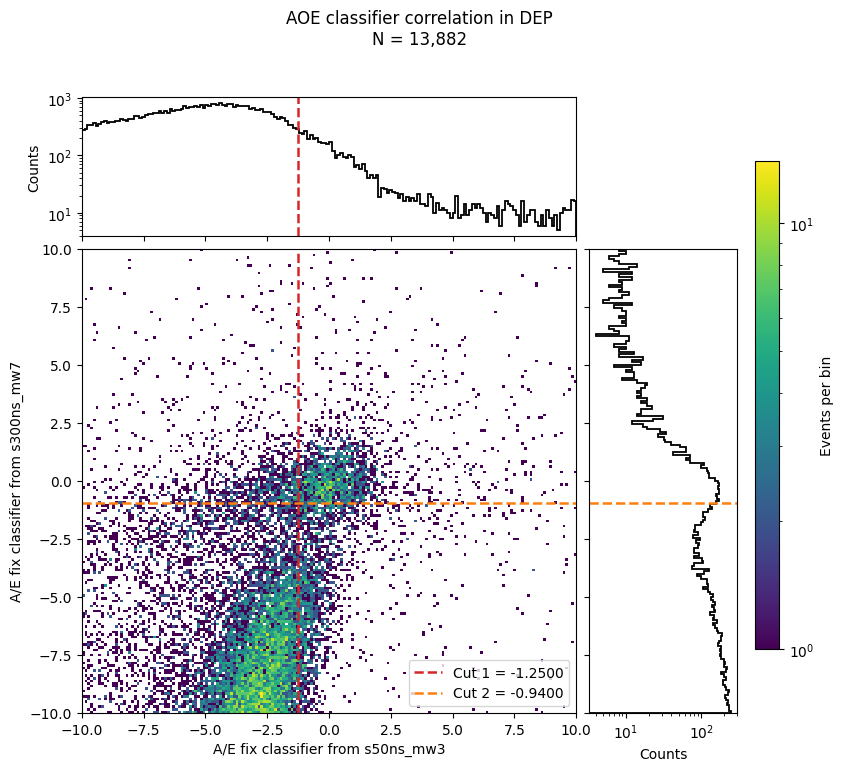

In [42]:
# zoomed in plot
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in DEP\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

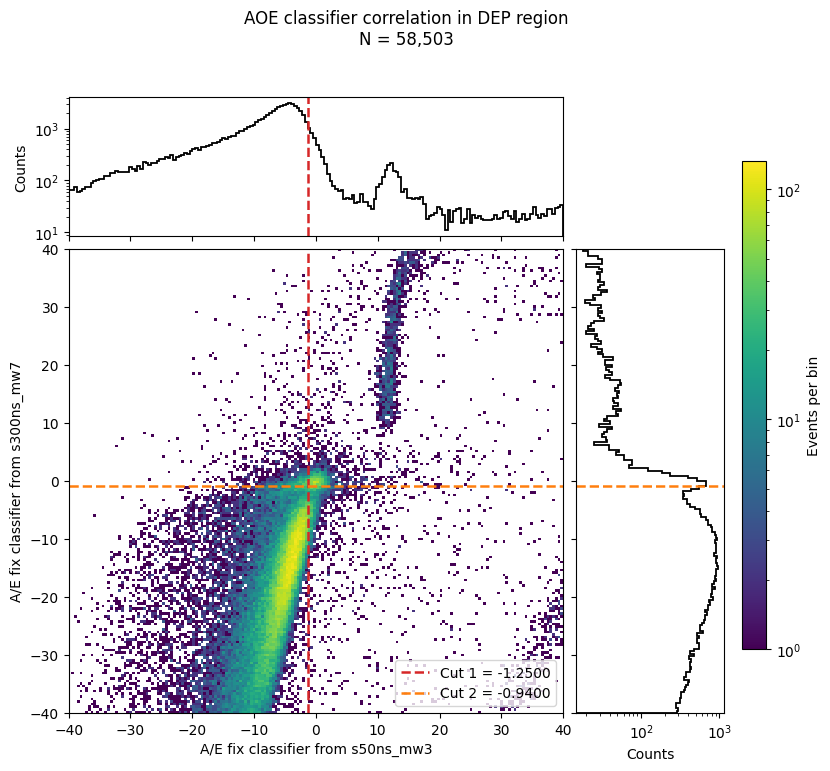

In [43]:
# full range plot
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in DEP region\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

## FEP

### readfile

In [20]:
pathlist = "cal_pathlist"

In [21]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_1][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_1][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db[run_1][pathlist])
low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_1][pathlist])

In [22]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)
low_cut_1 = np.asarray(low_cut_1)

In [23]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_2][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_2][pathlist])
is_valid_waveform_2= lh5.read("ch002/hit/is_valid_waveform",run_db[run_2][pathlist])
low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_2][pathlist])

In [24]:
E_2 = np.asarray(E_2)
A_max_mw_o_E_Classifier_2= np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_2 = np.asarray(is_valid_waveform_2)
low_cut_2 = np.asarray(low_cut_2)   

In [25]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)

In [26]:
FEP_mask = (E_1 > 2605) & (E_1 < 2625)
cut_value_1 = survival_db[run_1]['cut_value_90']
cut_value_2 = survival_db[run_2]['cut_value_90']

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [28]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == FEP_mask.shape
    == low_cut_1.shape
    == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"FEP_mask={FEP_mask.shape}, "
    f"low_cut_1={low_cut_1.shape}, "
    f"low_cut_2={low_cut_2.shape}"
)

# FEP selection plus finite classifier values
selection = (
    FEP_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# Selected Boolean cut decisions
pass_1 = low_cut_1[selection]
pass_2 = low_cut_2[selection]

print(f"Selected FEP events: {len(x):,}")

Selected FEP events: 36,440


### plt

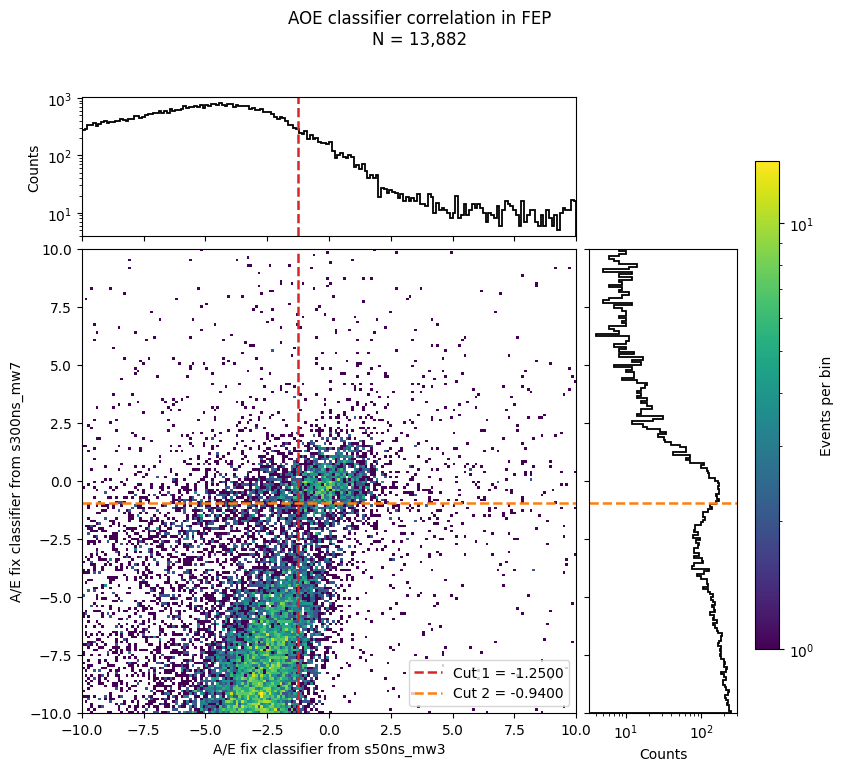

In [44]:
# zoomed in plot
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
# y_range = tuple(np.percentile(y, [0.2, 99.8]))
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in FEP\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

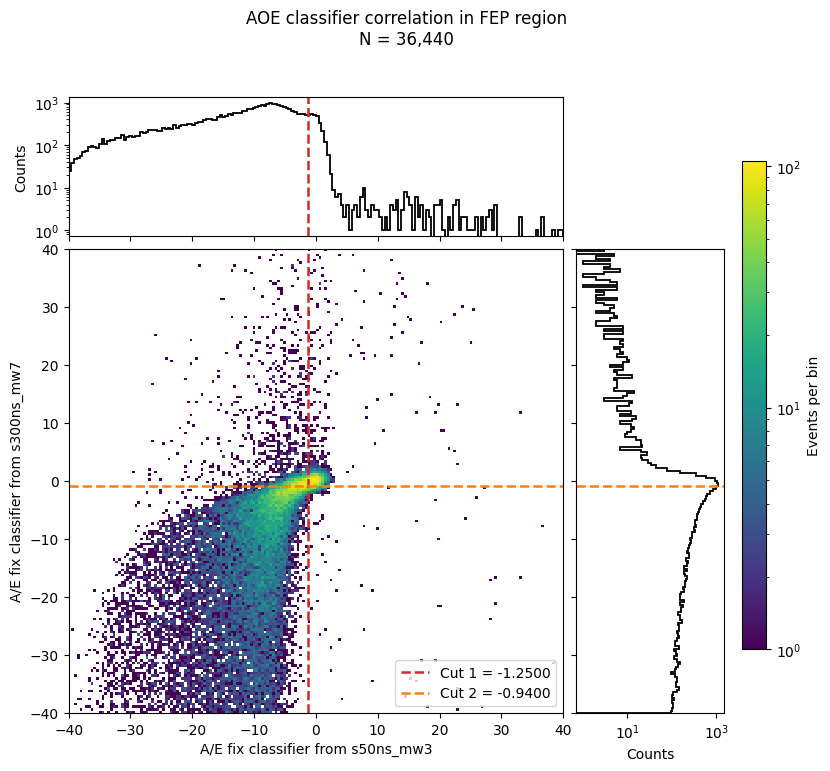

In [ ]:
# full range plot
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in FEP region\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

## ROI

### readfiles

In [31]:
pathlist = "phy_signal_pathlist"

In [32]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_1][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_1][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db[run_1][pathlist])
low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_1][pathlist])

In [33]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)
low_cut_1 = np.asarray(low_cut_1)

In [34]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run_2][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run_2][pathlist])
is_valid_waveform_2= lh5.read("ch002/hit/is_valid_waveform",run_db[run_2][pathlist])
low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run_2][pathlist])

In [35]:
E_2 = np.asarray(E_2)
A_max_mw_o_E_Classifier_2= np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_2 = np.asarray(is_valid_waveform_2)
low_cut_2 = np.asarray(low_cut_2)   

In [36]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)

In [37]:
ROI_mask = (E_1 > 1839) & (E_1 < 2239)
cut_value_1 = survival_db[run_1]['cut_value_90']
cut_value_2 = survival_db[run_2]['cut_value_90']

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [39]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == ROI_mask.shape
    == low_cut_1.shape
    == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    f"low_cut_1={low_cut_1.shape}, "
    f"low_cut_2={low_cut_2.shape}"
)

# DEP selection plus finite classifier values
selection = (
    ROI_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# Selected Boolean cut decisions
pass_1 = low_cut_1[selection]
pass_2 = low_cut_2[selection]

print(f"Selected ROI events: {len(x):,}")

Selected ROI events: 76,648


### plots

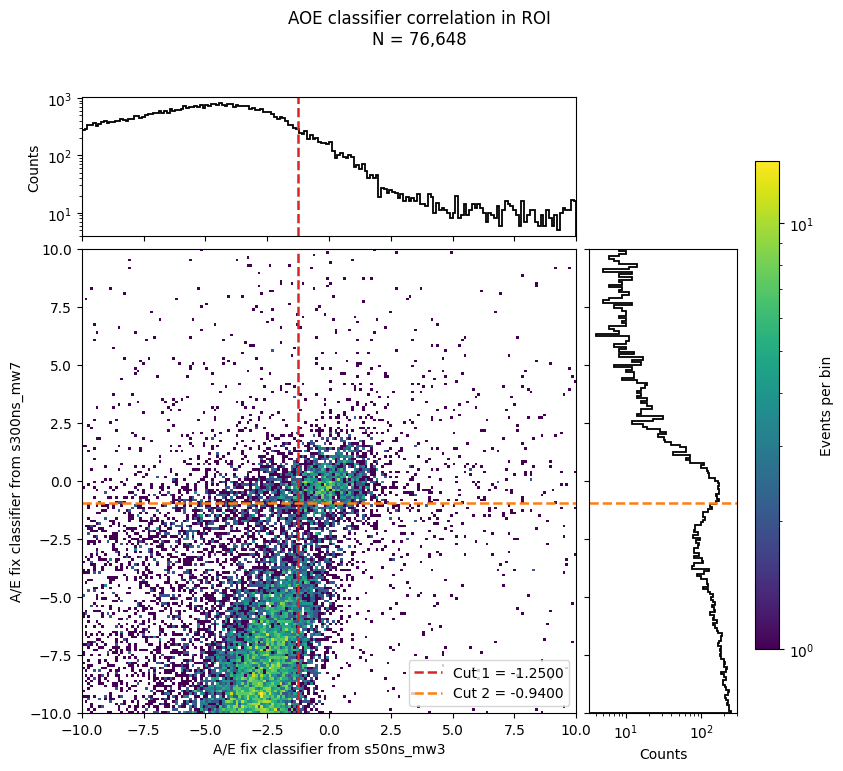

In [ ]:
# zoomed in plot
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in ROI\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

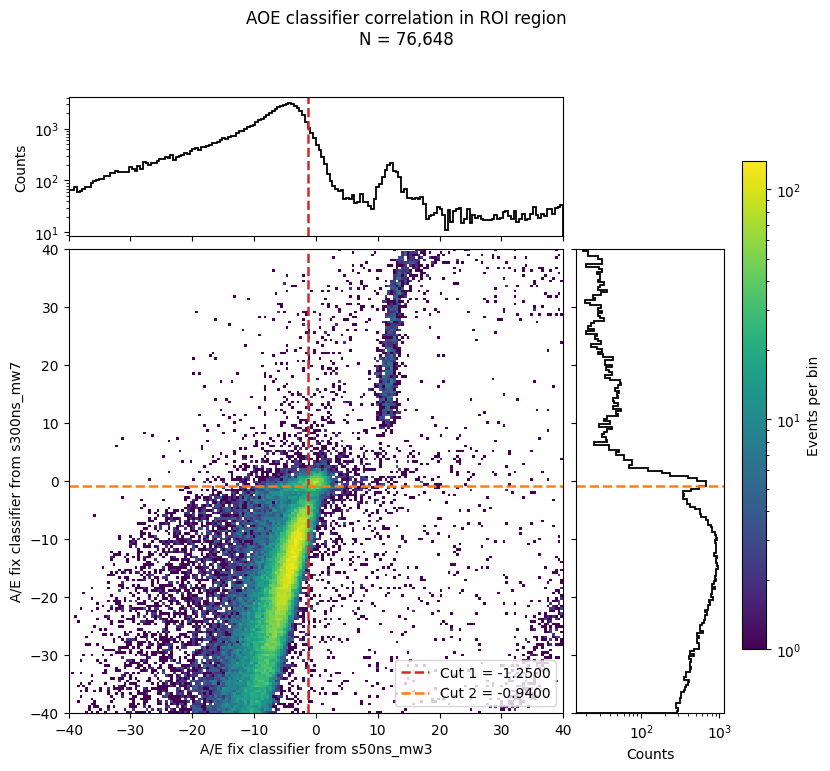

In [ ]:
# full range plot
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in ROI region\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()